# Task 1: Retail Sales – Exploratory Data Analysis
**Oasis Infobyte Internship (OIBSIP) — Data Analytics Track**

**Author:** Karan Verma

**Objective:** Explore a retail transactions dataset to understand sales patterns across product categories, customer demographics, and time, and pull out insights that could inform business decisions (e.g. stocking, staffing, marketing focus).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)
pd.set_option('display.max_columns', None)
print('Libraries loaded.')

Libraries loaded.


## Step 1: Load the Dataset

In [5]:
df = pd.read_csv('retail_sales_dataset.csv')
print(df.head().to_string())

   Transaction ID        Date Customer ID  Gender  Age Product Category  Quantity  Price per Unit  Total Amount
0               1  2023-11-24     CUST001    Male   34           Beauty         3              50           150
1               2  2023-02-27     CUST002  Female   26         Clothing         2             500          1000
2               3  2023-01-13     CUST003    Male   50      Electronics         1              30            30
3               4  2023-05-21     CUST004    Male   37         Clothing         1             500           500
4               5  2023-05-06     CUST005    Male   30           Beauty         2              50           100


## Step 2: Initial Inspection
Before doing any analysis, check the shape, data types, and whether there are missing values or duplicate rows — this tells us how much cleaning is needed.

In [6]:
print('Shape (rows, columns):', df.shape)
print()
print('Data types:')
print(df.dtypes)

Shape (rows, columns): (1000, 9)

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [7]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


In [8]:
print('Summary statistics (numeric columns):')
print(df.describe().to_string())

Summary statistics (numeric columns):
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


**Observation:** The dataset is already clean — 1000 rows, 9 columns, zero missing values, and no duplicate rows. The only real cleaning step needed is converting `Date` from text to an actual datetime type so we can pull out month and weekday.

## Step 3: Data Cleaning & Feature Engineering

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['MonthNum'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.day_name()

bins = [18, 25, 35, 45, 55, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('New columns added: Month, MonthNum, Weekday, AgeGroup')
print(df[['Date','Month','Weekday','AgeGroup']].head().to_string())

Date range: 2023-01-01 to 2024-01-01
New columns added: Month, MonthNum, Weekday, AgeGroup
        Date     Month   Weekday AgeGroup
0 2023-11-24  November    Friday    25-34
1 2023-02-27  February    Monday    25-34
2 2023-01-13   January    Friday    45-54
3 2023-05-21       May    Sunday    35-44
4 2023-05-06       May  Saturday    25-34


## Step 4: Univariate Analysis
Looking at each variable on its own before comparing them against each other.

/tmp/ipykernel_1903/125324378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


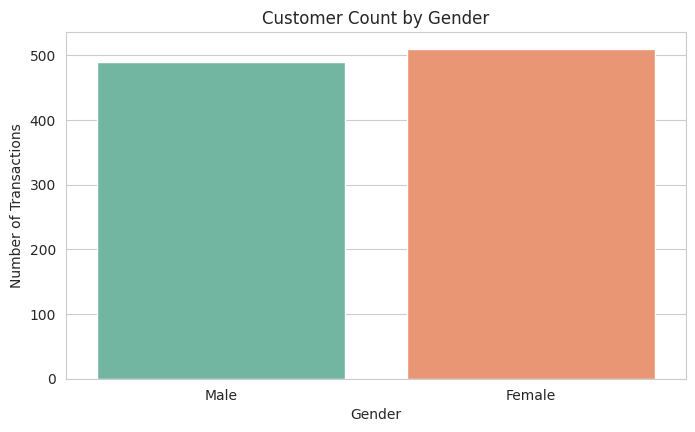

In [10]:
plt.figure()
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Customer Count by Gender')
plt.ylabel('Number of Transactions')
plt.show()

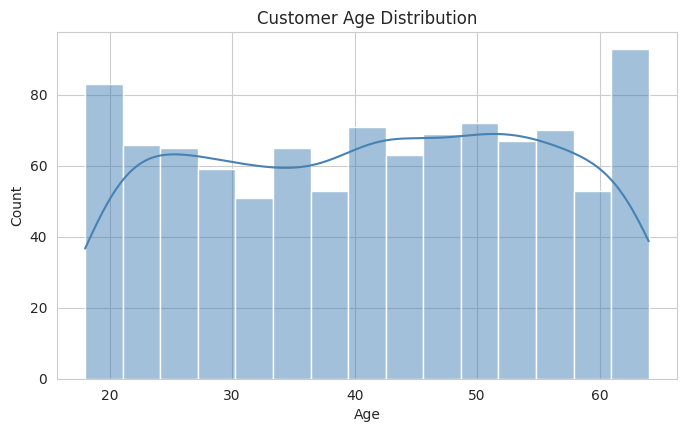

In [11]:
plt.figure()
sns.histplot(df['Age'], bins=15, kde=True, color='steelblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.show()

/tmp/ipykernel_1903/3336519269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product Category', order=df['Product Category'].value_counts().index, palette='Set3')


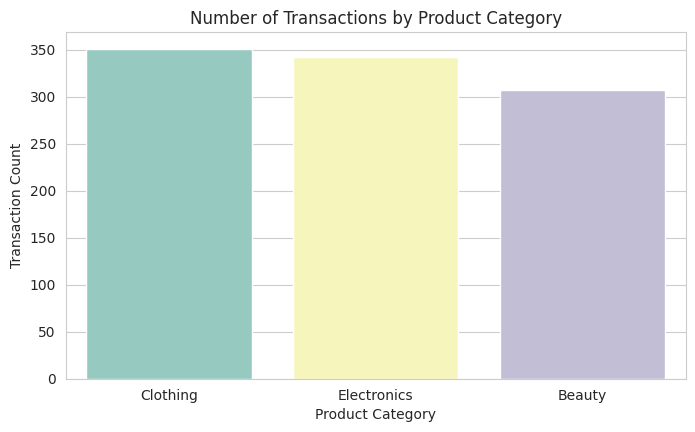

In [12]:
plt.figure()
sns.countplot(data=df, x='Product Category', order=df['Product Category'].value_counts().index, palette='Set3')
plt.title('Number of Transactions by Product Category')
plt.ylabel('Transaction Count')
plt.show()

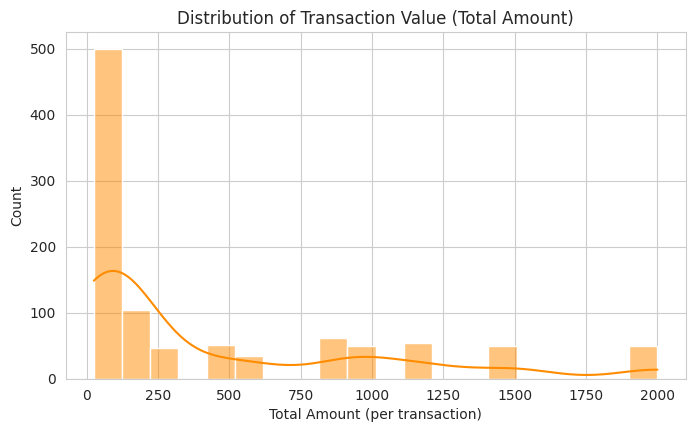

In [13]:
plt.figure()
sns.histplot(df['Total Amount'], bins=20, kde=True, color='darkorange')
plt.title('Distribution of Transaction Value (Total Amount)')
plt.xlabel('Total Amount (per transaction)')
plt.show()

**Observation:** The customer base is close to an even gender split, ages range from 18 to 64 with a fairly even spread, and all three product categories (Beauty, Clothing, Electronics) get a similar number of transactions. Transaction value is right-skewed — most purchases are low-value, with a smaller number of high-value ones pulling the average up.

## Step 5: Revenue Analysis (Bivariate)
Now comparing `Total Amount` (revenue) against category, gender, time, and age to find what actually drives sales.

                     sum        mean  count
Product Category                           
Electronics       156905  458.786550    342
Clothing          155580  443.247863    351
Beauty            143515  467.475570    307


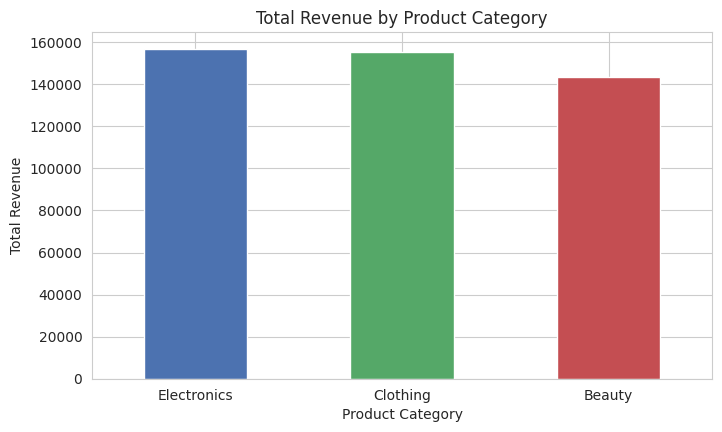

In [14]:
cat_rev = df.groupby('Product Category')['Total Amount'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
print(cat_rev)

plt.figure()
cat_rev['sum'].plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'])
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

           sum        mean  count
Gender                           
Female  232840  456.549020    510
Male    223160  455.428571    490


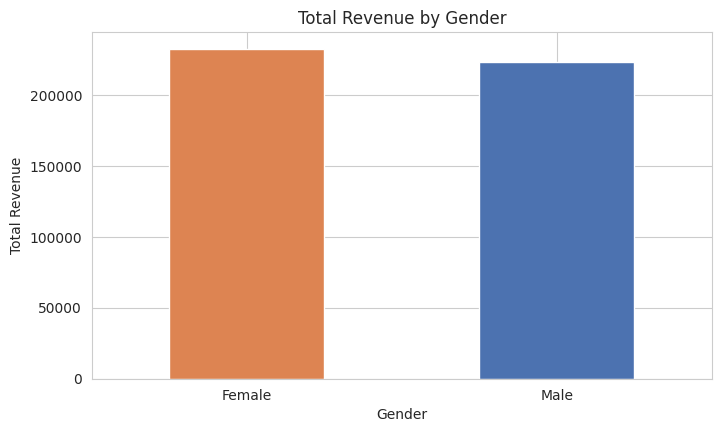

In [15]:
gender_rev = df.groupby('Gender')['Total Amount'].agg(['sum','mean','count'])
print(gender_rev)

plt.figure()
gender_rev['sum'].plot(kind='bar', color=['#DD8452','#4C72B0'])
plt.title('Total Revenue by Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

MonthNum
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64


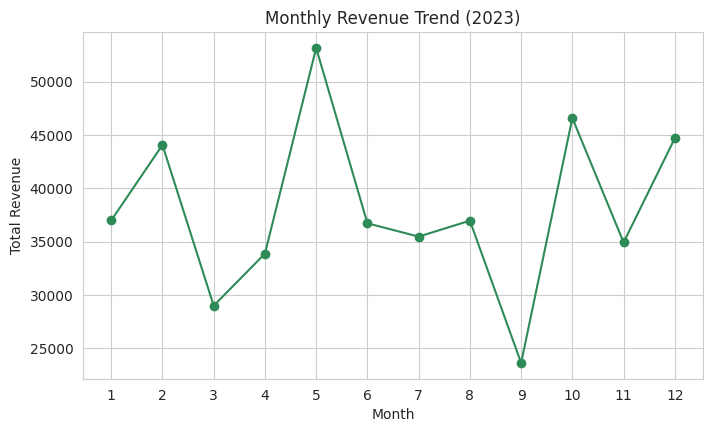

In [16]:
monthly_rev = df.groupby('MonthNum')['Total Amount'].sum()
print(monthly_rev)

plt.figure()
monthly_rev.plot(kind='line', marker='o', color='seagreen')
plt.title('Monthly Revenue Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(1,13))
plt.show()

             sum        mean  count
AgeGroup                           
18-24      84550  500.295858    169
25-34      98480  480.390244    205
35-44      91870  454.801980    202
45-54     100690  439.694323    229
55-64      80410  412.358974    195


/tmp/ipykernel_1903/2386777298.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rev = df.groupby('AgeGroup')['Total Amount'].agg(['sum','mean','count'])


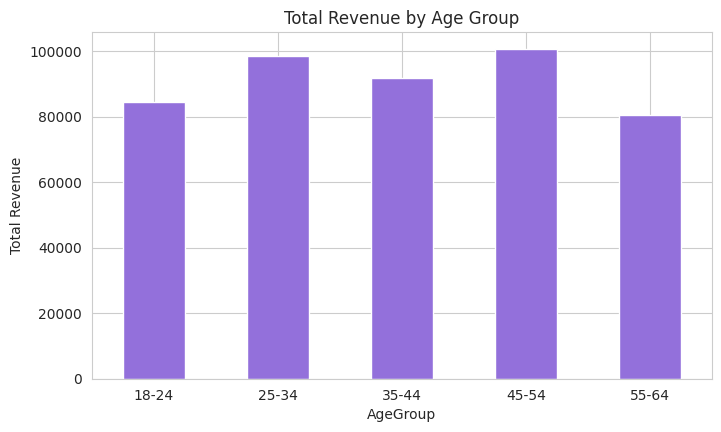

In [17]:
age_rev = df.groupby('AgeGroup')['Total Amount'].agg(['sum','mean','count'])
print(age_rev)

plt.figure()
age_rev['sum'].plot(kind='bar', color='mediumpurple')
plt.title('Total Revenue by Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

Weekday
Monday       70250
Tuesday      69440
Wednesday    58770
Thursday     53835
Friday       66290
Saturday     78815
Sunday       58600
Name: Total Amount, dtype: int64


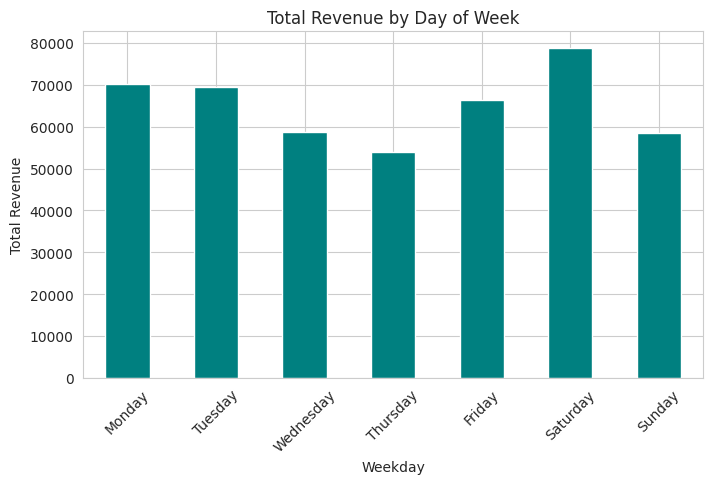

In [18]:
weekday_rev = df.groupby('Weekday')['Total Amount'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print(weekday_rev)

plt.figure()
weekday_rev.plot(kind='bar', color='teal')
plt.title('Total Revenue by Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

                 Age  Quantity  Price per Unit  Total Amount
Age             1.00     -0.02           -0.04         -0.06
Quantity       -0.02      1.00            0.02          0.37
Price per Unit -0.04      0.02            1.00          0.85
Total Amount   -0.06      0.37            0.85          1.00


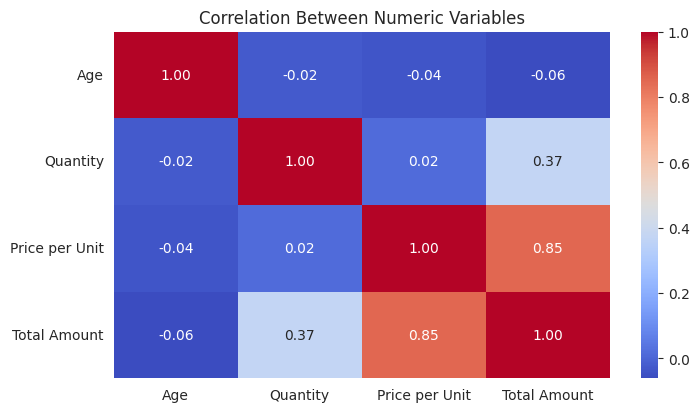

In [19]:
corr = df[['Age','Quantity','Price per Unit','Total Amount']].corr()
print(corr.round(2))

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Variables')
plt.show()

## Key Insights

1. **Revenue is balanced across categories, not dominated by one.** Electronics narrowly leads (₹1,56,905), just ahead of Clothing (₹1,55,580) and Beauty (₹1,43,515) — the gap between the top and bottom category is under 9%.

2. **Female customers contribute slightly more revenue** (₹2,32,840 vs. ₹2,23,160 for male customers) and a marginally higher average order value, though the overall split is close to even.

3. **Price per unit drives revenue far more than quantity or age.** Total Amount correlates strongly with Price per Unit (0.85), moderately with Quantity (0.37), and barely at all with Age (-0.06) — high-ticket items matter much more than how many units someone buys, and age isn't a useful signal for predicting spend.

4. **Spending habits shift by age group, but not in product preference.** The 45-54 group generates the most total revenue (₹1,00,690) simply by transacting more often, while 18-24 year-olds spend the most per visit on average (₹500) — i.e. younger customers buy less often but spend more each time.

5. **Saturday is the strongest sales day** (₹78,815) and **Thursday the weakest** (₹53,835), pointing to a weekend-shopping pattern that could inform staffing or promotional timing.

6. **No clean seasonal trend across the year** — monthly revenue swings between ₹23,620 (September) and ₹53,150 (May) without a steady upward or seasonal pattern, suggesting revenue at this scale is driven more by individual high-value transactions than by a calendar effect.

## Conclusion

This dataset shows a retail business with broadly balanced demand across product categories and customer genders, where the **price point of what's being sold matters far more than who is buying it or how much of it they buy**. The clearest actionable patterns are the **Saturday sales peak** and the **higher average order value among 18-24 year-olds** — both useful angles for promotional timing and targeted marketing. With a larger dataset (e.g. multiple years), it would be worth re-checking the monthly trend for genuine seasonality rather than the transaction-level noise seen here.